In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile, assemble, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator, DensityMatrix, partial_trace
import scipy 
from functools import reduce
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.synthesis import SuzukiTrotter
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

In [2]:
def pauli_str_to_unitary(pstr):
    def char_to_pauli(c):
        if c == "I":
            return np.eye(2)
        elif c == "X":
            return np.array([[0, 1], [1, 0]])
        elif c == "Y":
            return np.array([[0, -1j], [1j, 0]])
        elif c == "Z":
            return np.array([[1, 0], [0, -1]])
        else:
            raise ValueError(f"Invalid Pauli character: {c}")
    
    return reduce(np.kron, [char_to_pauli(c) for c in pstr], np.array([[1]]))

def expect(state, H):
    if state.ndim == 1:
        res = state.conj().T @ H @ state
    else:
        rho = state
        res = np.trace(rho @ H)
    
    assert np.isclose(res.imag, 0)
    return res.real # real-valued observables

def outer(state):
    psi = state.reshape(-1, 1)
    return psi @ psi.conj().T

def trdist(rho, sigma):
    return np.sum(np.abs(np.linalg.svdvals(rho-sigma))) / 2

def spin_cov(rho, spin_ind):
    n = int(np.log2(rho.shape[0]))
    pstr = list('I'*n)
    pstr[spin_ind] = 'X'
    expect_Xi = expect(rho, pauli_str_to_unitary(pstr))
    pstr[spin_ind+1] = 'X'
    expect_XiXiplus1 = expect(rho, pauli_str_to_unitary(pstr))
    pstr[spin_ind] = 'I'
    expect_Xiplus1 = expect(rho, pauli_str_to_unitary(pstr))
    spin_cov = expect_XiXiplus1 - expect_Xi*expect_Xiplus1
    return spin_cov
    
def sample_gcauchy(beta, M=1):
    cs = []
    # pdf = lambda u: 1/np.pi * 1/(1+(u/np.sqrt(2))**4) ~ C_{1/sqrt2}^4
    thresh = (1+np.sqrt(5))/2 # sup u of pdf(u)/cauchypdf(u) = golden ratio
    while len(cs) < M:
        c = scipy.stats.cauchy.rvs()
        u = scipy.stats.uniform.rvs()
        h = (1+c**2)/(1+(c/np.sqrt(2))**4)
        if u < h/thresh:
            cs.append(c)

    return beta*(np.array(cs) if M > 1 else cs[0])

In [3]:
import numpy as np
from qiskit import QuantumCircuit

def ite_pauli_gadget(
    qc: QuantumCircuit,
    anc,            # ancilla qubit (QuantumRegister element)
    cbit,           # classical bit (Clbit) to store ancilla measurement
    pauli,          # e.g. "ZZII", "XIII", can also be list like ['Z','Z','I','I']
    gamma_dtau,     # scalar = γ * Δτ  (can be positive or negative)
    *,
    data_qubits=None,   # optional list of data qubits to use; defaults to 0..n-1
    postselect_on=0,    # this circuit measures; you postselect shots with this outcome
):
    """
    Paper-faithful gadget for nonunitary exp(-|γ|Δτ) exp(-γΔτ P) using mid-circuit measurement and postselection.

    - Sign handling matches the paper: for γ>0 vs γ<0, use X-conjugation on the parity qubit.
    - Uses basis changes + CNOT ladder over the SUPPORT of P (non-identity positions).
    - Applies a controlled-Rx(φ) with φ = 2 arccos(exp(-2|γ|Δτ)).
    - Measures ancilla into cbit and resets ancilla.

    NOTE: This function only BUILDS the circuit. Actual postselection is done in simulation
    by keeping shots where measured ancilla bit equals `postselect_on`.
    """
    # normalize pauli to string
    if isinstance(pauli, (list, tuple)):
        pauli = ''.join(pauli)
    n = len(pauli)

    if data_qubits is None:
        data_qubits = list(range(n))
    if len(data_qubits) != n:
        raise ValueError("data_qubits length must match pauli string length")

    # support: only qubits where P != I participate
    supp = [i for i, p in enumerate(pauli) if p != "I"]
    if len(supp) == 0:
        # term is identity -> exp(-γΔτ I) is a scalar; ignore in state update
        return qc

    # magnitude and sign
    mag = abs(gamma_dtau)
    sign = 1 if gamma_dtau > 0 else (-1 if gamma_dtau < 0 else 0)
    if sign == 0:
        return qc

    # --- 1) Basis change on support so term becomes Z...Z on the support ---
    # X -> H X H = Z ; Y -> (S† H) Y (H S) = Z
    for i in supp:
        q = data_qubits[i]
        if pauli[i] == "X":
            qc.h(q)
        elif pauli[i] == "Y":
            qc.sdg(q)
            qc.h(q)
        elif pauli[i] == "Z":
            pass

    # --- 2) CNOT ladder over support to map product Z...Z to Z on parity qubit ---
    chain = [data_qubits[i] for i in supp]    # increasing order of indices in pauli
    for a, b in zip(chain[:-1], chain[1:]):
        qc.cx(a, b)

    parity_q = chain[-1]  # holds the Z-parity (product) in this basis

    # --- 3) Sign handling per paper: X-conjugate on parity qubit when gamma_dtau > 0 ---
    # Paper’s relation: diag(e^{-2|γ|Δτ},1) = X diag(1,e^{-2|γ|Δτ}) X.
    # Their base gadget is typically written for γ<0. So if γ>0, do X ... X around the filter.
    do_x_conjugation = (gamma_dtau > 0)
    if do_x_conjugation:
        qc.x(parity_q)

    # --- 4) The nonunitary filter block (controlled-Rx, measure ancilla, reset) ---
    # ancilla starts in |0>. If parity_q=1, ancilla rotates, and postselecting anc=0
    # applies amplitude factor cos(phi/2)=exp(-2|γ|Δτ) to that branch.
    phi = 2 * np.arccos(np.exp(-2 * mag))
    qc.crx(phi, parity_q, anc)
    qc.measure(anc, cbit)
    qc.reset(anc)

    # undo X-conjugation for gamma>0 case
    if do_x_conjugation:
        qc.x(parity_q)

    # --- 5) Uncompute ladder ---
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]):
        qc.cx(a, b)

    # --- 6) Undo basis change ---
    for i in reversed(supp):
        q = data_qubits[i]
        if pauli[i] == "X":
            qc.h(q)
        elif pauli[i] == "Y":
            qc.h(q)
            qc.s(q)

    return qc

In [4]:
def circ_ITE_pauli(qc: QuantumCircuit, anc_qbit, cbit, s, beta): 
    """s = pauli, circ for e^{-beta s} for beta > 0"""
    n = len(s)
    flip = True
    if beta <= 0:
        beta = -beta
        flip = False
    
    # conjugation, LHS - flip (add negative sign via conjugation)
    if flip:
        if s[0] in 'ZY':
            qc.x(0)
        elif s[0] == 'X':
            qc.z(0)
    
    for i in range(n):
        if s[i] == 'X':
            qc.h(i)
        elif s[i] == 'Y':
            qc.sdg(i)
            qc.h(i)
    
    # e^{-beta Z^{n}} gadget for beta < 0
    # for i in range(n):
    #     qc.x(i)

    for i in range(n-1):
        qc.cx(i, i+1)

    phi = 2*np.arccos(np.exp(-2*np.abs(beta)))
    qc.crx(phi, n-1, anc_qbit)
    qc.measure(anc_qbit, cbit)
    qc.reset(anc_qbit)

    for i in range(n-2, -1, -1):
        qc.cx(i, i+1)

    # for i in range(n):
    #     qc.x(i)
    ## end of e^{-beta Z^{n}} gadget
        
    # conjugation, RHS
    for i in range(n-1, -1, -1):
        if s[i] == 'X':
            qc.h(i)
        elif s[i] == 'Y':
            qc.h(i)
            qc.s(i)
    
    # conjugation, RHS - flip
    if flip:
        if s[0] in 'ZY':
            qc.x(0)
        elif s[0] == 'X':
            qc.z(0)

    return qc

def exact_ITE_pauli(s, beta):
    P = pauli_str_to_unitary(s)
    return scipy.linalg.expm(-beta*P)*np.exp(-beta)

import numpy as np
from qiskit import QuantumCircuit

def rte_pauli_gadget(qc: QuantumCircuit, P: str, theta: float, qubits=None):
    """Append exp(-i * theta * P) for Pauli string P (e.g. 'IXYZ')."""
    n = len(P)
    if qubits is None:
        qubits = list(range(n))
    supp = [i for i,p in enumerate(P) if p != "I"]
    if not supp:
        return qc  # global phase only

    # basis change to Z on support
    for i in supp:
        q = qubits[i]
        if P[i] == "X":
            qc.h(q)
        elif P[i] == "Y":
            qc.sdg(q); qc.h(q)

    # parity ladder on support
    chain = [qubits[i] for i in supp]
    for a, b in zip(chain[:-1], chain[1:]):
        qc.cx(a, b)

    # Z-rotation: exp(-i theta Z) == Rz(2*theta) up to global phase
    qc.rz(2 * theta, chain[-1])

    # uncompute
    for a, b in zip(chain[-2::-1], chain[-1:0:-1]):
        qc.cx(a, b)

    # undo basis change
    for i in reversed(supp):
        q = qubits[i]
        if P[i] == "X":
            qc.h(q)
        elif P[i] == "Y":
            qc.h(q); qc.s(q)

    return qc



In [5]:
import math
from typing import Iterable, List, Sequence, Tuple, Union

PauliTerm = Union[str, Tuple[str, float]]  # allow "ZZX" or ("ZZX", weight)

def trotter_pauli(
    terms: Sequence[PauliTerm],
    alpha: float,
    *,
    steps: int = 1,
    order: int = 2,
) -> List[Tuple[str, float]]:
    """
    Return a 'schedule' approximating exp(alpha * sum_i w_i P_i) using Suzuki–Trotter.

    Args:
        terms:
            Sequence of Pauli terms. Each entry can be either:
              - a Pauli string like "ZZX" (weight assumed 1.0), or
              - a tuple ("ZZX", w) meaning term weight w.
            Interpreted as H = sum_i w_i P_i.
        alpha:
            Total evolution coefficient (e.g., alpha = -beta for ITE exp(-beta H)).
        steps:
            Number of Trotter steps (time slices). Uses x = alpha/steps per step.
        order:
            1 for Lie–Trotter, or an even integer 2,4,6,... for symmetric Suzuki.

    Returns:
        schedule: list of (pauli_string, coeff) entries.
        Applying the approximation means iterating schedule in order and applying
        exp(coeff * pauli_string) for each entry.

    Notes:
        - If you later want exp(alpha * H) where H = sum w_i P_i,
          each item becomes exp(coeff * w_i * P_i) effectively because we fold w_i into coeff.
    """
    if steps <= 0:
        raise ValueError("steps must be positive")
    if not (order == 1 or (order > 0 and order % 2 == 0)):
        raise ValueError("order must be 1 or an even positive integer (2,4,6,...)")

    # Normalize input: list of (P, w)
    norm_terms: List[Tuple[str, float]] = []
    for t in terms:
        if isinstance(t, str):
            norm_terms.append((t, 1.0))
        else:
            P, w = t
            norm_terms.append((P, float(w)))

    def S(x: float, o: int) -> List[Tuple[str, float]]:
        # One-step schedule approximating exp(x * sum_i w_i P_i)
        if o == 1:
            # forward product
            return [(P, x * w) for (P, w) in norm_terms]

        if o == 2:
            half = x / 2.0
            forward = [(P, half * w) for (P, w) in norm_terms]
            backward = list(reversed(forward))
            return forward + backward

        # higher even order Suzuki recursion
        p = 1.0 / (4.0 - 4.0 ** (1.0 / (o - 1)))
        return S(p * x, o - 2) + S((1.0 - 2.0 * p) * x, o - 2) + S(p * x, o - 2)

    x = alpha / steps
    one_step = S(x, order)

    # Repeat the schedule for each Trotter step
    return one_step * steps

In [6]:

# --- helper: drop a measured ancilla qubit from a full statevector ---
def drop_measured_qubit(full_sv: Statevector, ancilla_q: int, ancilla_outcome: int) -> Statevector:
    """
    Returns the statevector on the other (num_qubits-1) qubits, assuming ancilla_q
    is collapsed to |ancilla_outcome> and is not entangled anymore.
    Qiskit ordering is |q_{n-1}...q_0>, so axis = (num_qubits - 1 - qubit_index).
    """
    num_qubits = int(np.log2(len(full_sv.data)))
    tensor = np.asarray(full_sv.data).reshape([2] * num_qubits)
    axis = num_qubits - 1 - ancilla_q
    sliced = np.take(tensor, indices=ancilla_outcome, axis=axis)   # remove that axis
    vec = sliced.reshape(2 ** (num_qubits - 1))
    vec = vec / np.linalg.norm(vec)
    return Statevector(vec)


def drop_measured_qubit_dm(rho, ancilla_q: int, ancilla_outcome: int = 0) -> DensityMatrix:
    """
    Given an n-qubit density matrix rho, project qubit ancilla_q onto |ancilla_outcome>
    and trace it out. Returns the (n-1)-qubit conditional density matrix.

    Qiskit qubit ordering is |q_{n-1} ... q_0>, so ancilla_q corresponds to tensor axis:
        axis = n - 1 - ancilla_q
    """
    # accept DensityMatrix or array-like
    if isinstance(rho, DensityMatrix):
        mat = np.asarray(rho.data)
    else:
        mat = np.asarray(rho)

    dim = mat.shape[0]
    n = int(np.log2(dim))
    if mat.shape != (2**n, 2**n):
        raise ValueError(f"rho must be square with dimension 2^n; got {mat.shape}")

    if ancilla_outcome not in (0, 1):
        raise ValueError("ancilla_outcome must be 0 or 1")

    axis = n - 1 - ancilla_q  # tensor axis for this qubit in Qiskit ordering

    # reshape rho into 2n indices: (bra qubits..., ket qubits...)
    tens = mat.reshape([2]*n + [2]*n)

    # project on ancilla outcome: select that index on both bra and ket for the ancilla axis
    # bra axis = axis, ket axis = n + axis
    tens_proj = np.take(tens, ancilla_outcome, axis=axis)
    tens_proj = np.take(tens_proj, ancilla_outcome, axis=n + axis - 1)
    # (note: after first take, total rank drops by 1, so ket axis shifts by -1)

    # now tens_proj has (n-1) bra axes + (n-1) ket axes
    mat_proj = tens_proj.reshape(2**(n-1), 2**(n-1))

    # renormalize (conditional on getting this outcome)
    p = np.real_if_close(np.trace(mat_proj))
    p = float(np.real(p))
    if p <= 0:
        # no support on this outcome
        return DensityMatrix(mat_proj)  # will be (near) zero; caller can handle
    mat_proj = mat_proj / p

    return DensityMatrix(mat_proj)

In [7]:
def spin_chain_H_terms(n, J=1, g=1, type="transverse"):
    if type == "transverse":
        Hzzs = []
        Hxs = []
        for i in range(n):
            if i < n-1:
                pstr = list("I"*n)
                pstr[i] = pstr[i+1] = "Z"
                Hzzs.append(pstr)
            
            pstr = list("I"*n)
            pstr[i] = "X"
            Hxs.append(pstr)

        Hs = []
        for Hzz in Hzzs:
            Hs.append((Hzz, -J))

        for Hx in Hxs:
            Hs.append((Hx, -J*g))
    
    return Hs

n = 4
g = 1.4
J = 1.0
omega = 1.0
excited_ind = 0
# Hs = [("ZZZZ", 1.0)]
Hs = spin_chain_H_terms(n, J=J, g=g)

def H_to_matrix(Hs, *, qiskit_order=False) -> float:
    n = len(Hs[0][0])
    Hmat = np.zeros((2**n, 2**n), dtype=complex)
    for t in Hs:
        if isinstance(t, str):
            P, w = t, 1.0
        else:
            P, w = t[0], float(t[1])
        if not qiskit_order:
            P = P[::-1]
        Hmat += w * Operator.from_label(''.join(P)).data
    return Hmat

Hmat = H_to_matrix(Hs)
    

def run_one_randomized(beta, shots=2000, trotter=(10, 1), method="r-ite", noise_model=None):
    Hs_trotterized_ite = trotter_pauli(Hs, beta, steps=trotter[0], order=trotter[1])
    t = sample_gcauchy(beta)
    Hs_trotterized_rte = trotter_pauli(Hs, t, steps=trotter[0], order=trotter[1])

    main_qreg = QuantumRegister(n)
    anc_qreg = QuantumRegister(1)
    creg = ClassicalRegister(len(Hs_trotterized_ite))
    qc = QuantumCircuit(main_qreg, anc_qreg, creg)

    for i in range(n):
        qc.h(i)

    for j, (P, coeff) in enumerate(Hs_trotterized_ite):
        ite_pauli_gadget(qc, anc_qreg[0], creg[j], P, gamma_dtau=coeff)
    
    if method == "r-ite":
        for j, (P, coeff) in enumerate(Hs_trotterized_rte):
            rte_pauli_gadget(qc, P, coeff, qubits=None)
        
    qc.save_density_matrix(label="rho", pershot=True)

    sim = AerSimulator(method="density_matrix", noise_model=noise_model)
    tqc = transpile(qc, sim)
    res = sim.run(tqc, shots=shots, memory=True).result()

    rhos = res.data(tqc)["rho"]
    mem = res.get_memory(tqc)

    keep = [k for k, bits in enumerate(mem) if set(bits) <= {"0"}]
    if not keep:
        return None  # no successful trajectory

    # all kept shots are identical within this circuit, so take the first
    rho_proj = drop_measured_qubit_dm(rhos[keep[0]], ancilla_q=n, ancilla_outcome=0)
    return rho_proj

def run_randomized_ite(beta, samples=10, shots=5000, trotter=(10, 1), method="ite", noise_model=None):
    rhos = []
    for _ in range(samples):  # 100 randomizations
        r = run_one_randomized(beta=beta, shots=shots, trotter=trotter, method=method, noise_model=noise_model)
        if r is not None:
            rhos.append(r)
    
    rho = np.zeros((2**n, 2**n), dtype=complex)
    k = len(rhos)
    for r in rhos:
        rho += np.array(r.data)
    rho /= k
    print("BETA", beta, "method", method, "samples", k)
    return rho, k

data = []
betas = np.linspace(1e-3, 1, 10)
samples = 10
trotter = (10, 2)
shots = 1000
noise = 1e-4
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 1), ["x","h","s","sdg","rz","rx"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(noise, 2), ["cx","crx"])

def compute_for_beta(beta):
    print("BETA", beta)
    rho_rite, samples_rite = run_randomized_ite(beta, samples=samples, shots=shots, trotter=trotter, noise_model=noise_model, method="r-ite")
    rho_ite, samples_ite = run_randomized_ite(beta, samples=samples, shots=shots, trotter=trotter, noise_model=noise_model, method="ite")
    return (rho_rite, samples_rite), (rho_ite, samples_ite)

# if __name__ == '__main__':
#     data = [compute_for_beta(beta) for beta in betas]


In [89]:
import pickle

with open(f'data_n{n}_g{g}_J{J}_circ_noise_{noise}.pkl', 'wb') as f:
    pickle.dump(data, f)

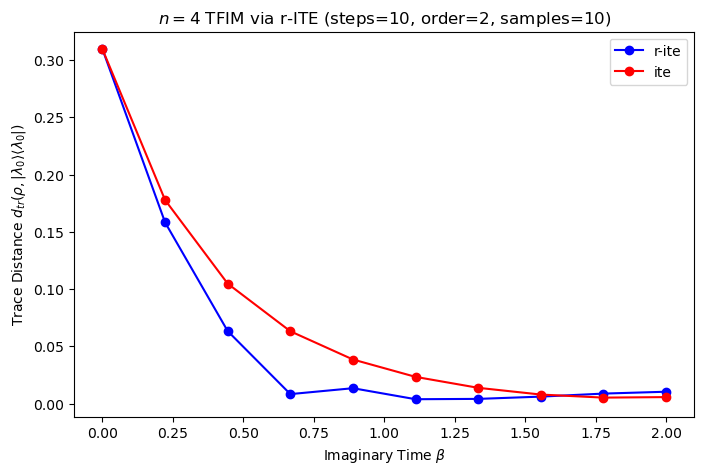

In [14]:
betas = np.linspace(1e-3, 2, 10)
import matplotlib.pyplot as plt
import numpy as np

eigenvals, eigenvecs = np.linalg.eigh(Hmat)
ground_state = eigenvecs[:, 0]
ground_rho = outer(ground_state)
rhos = np.array([(row[0][0], row[1][0]) for row in data])
trds = np.array([[trdist(c, ground_rho) for c in r] for r in rhos])

plt.figure(figsize=(8, 5))
plt.plot(
    betas, trds[:,0],
    marker='o',
    linestyle='-',
    color='blue',
    markerfacecolor='blue',
    label="r-ite"
)
plt.plot(
    betas, trds[:,1],
    marker='o',
    linestyle='-',
    color='red',
    markerfacecolor='red',
    label="ite"
)
plt.xlabel(r'Imaginary Time $\beta$')
plt.ylabel(r'Trace Distance $d_{tr}(\rho, |\lambda_0\rangle\langle\lambda_0|)$')
plt.title(fr'$n=4$ TFIM via r-ITE (steps=${trotter[0]}$, order=${trotter[1]}$, samples=${samples}$)')
plt.legend()
plt.show()

In [ ]:
here

0.0019970704753842286 0.0019942041578422803
0.1951794538137372 0.16510376713496003
0.29718276863669235 0.25091766607696375
0.3529949575856709 0.29724017593842533
0.3496857783380306 0.32322064394627115
0.3584937896102783 0.33843804874332895
0.3557920457749558 0.34782661449531055
0.3503619467055246 0.35401088345215526
0.3487808304512082 0.3584274457670076
0.34781248699975986 0.36188228940148887
0.001997014926183198 0.001992372132521271
0.23683813454743793 0.16499823701844424
0.2949178293722136 0.25079848678060734
0.3396306305267226 0.29712937935435546
0.3507497772643705 0.32312216711310215
0.34938432785694595 0.3383511198991399
0.35117968391732557 0.3477494335851631
0.34872304384631725 0.3539416557696564
0.28908567530720336 0.3583646413938267
0.32938489494700784 0.36182467007195224
0.0019577633549736004 0.001974169851419648
0.2241139062162345 0.16394682134629873
0.2846382681031716 0.24960944226844348
0.3325388504713131 0.29602315385602856
0.3402730207498444 0.3221385157943796
0.357120485

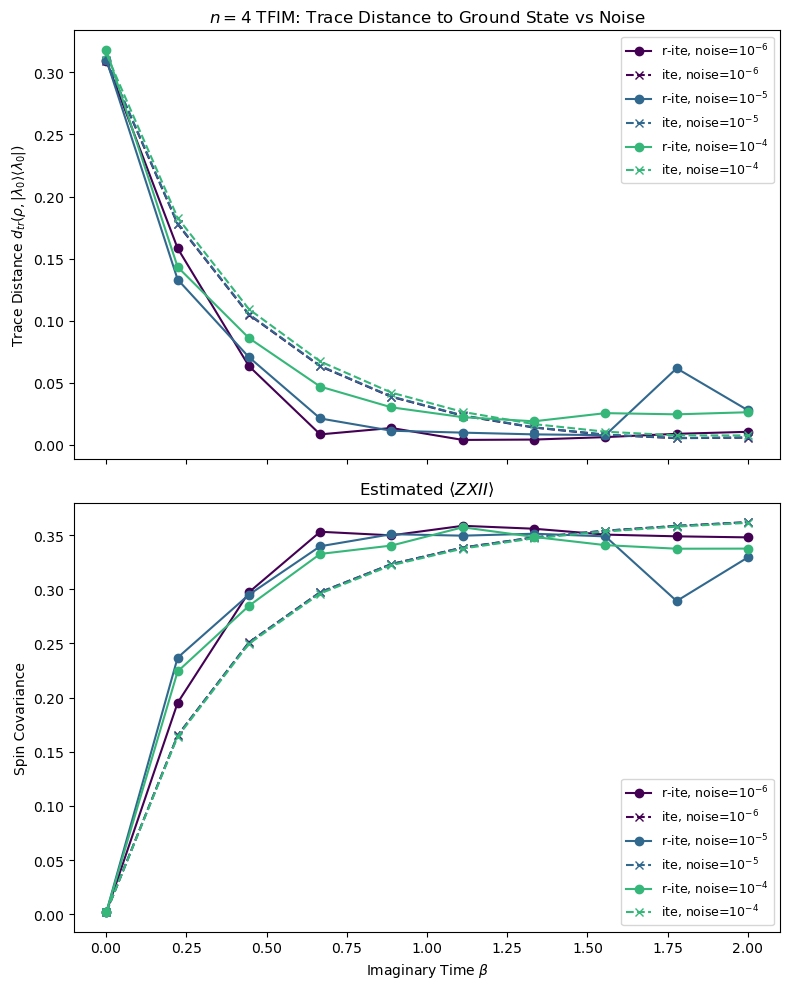

In [ ]:
import glob
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Glob all relevant data files with pattern matching your filename structure
data_files = glob.glob('./data/data_n4_g1.4_J1.0_circ_noise_*.pkl')

# Get a color map with enough colors for each noise level
from matplotlib import cm

num_curves = len(data_files)
colors = plt.cm.viridis(np.linspace(0, 1, num_curves))

def to_scientific(val):
    """Convert a float to '10^{-k}' scientific notation string for nice labeling."""
    if val == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(val))))
    return r"$10^{{{}}}$".format(exponent)

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
ax_dist, ax_cov = axes
spin_ind = 2

# Save for later reuse in plot titles
# pauli = "ZXII"

# ------ NOISY CURVES -------
for i, filepath in enumerate(sorted(data_files, key=lambda x: float(x.split('_noise_')[1][:-4]))):
    # Extract noise value from filename
    noise_str = filepath.split('_noise_')[1][:-4]
    noise_val = float(noise_str)
    if noise_val > 1e-4: continue
    noise_label = to_scientific(noise_val)

    with open(filepath, 'rb') as f:
        data = pickle.load(f)

    # For your file structure, each row[0][0] is (r-ITE), row[1][0] is (ITE)
    rhos = np.array([(row[0][0], row[1][0]) for row in data])
    trds = np.array([[trdist(c, ground_rho) for c in r] for r in rhos])

    # Compute spin covariance for each
    expects = []
    for beta_idx, row in enumerate(data):
        rho_r = row[0][0]
        rho_i = row[1][0]
        def corr(rho):
            zzii = expect(rho, pauli_str_to_unitary('ZZII'))
            ziii = expect(rho, pauli_str_to_unitary('ZIII'))
            izii = expect(rho, pauli_str_to_unitary('IZII'))
            return zzii - ziii*izii
        expect_r = corr(rho_r)
        expect_i = corr(rho_i)
        # print(expect_r, expect_i)
        expects.append((expect_r, expect_i))
    expects = np.array(expects)

    color = colors[i]
    # Trace distance plot
    ax_dist.plot(
        betas, trds[:,0],
        marker='o',
        linestyle='-',
        color=color,
        label=f"r-ite, noise={noise_label}"
    )
    ax_dist.plot(
        betas, trds[:,1],
        marker='x',
        linestyle='--',
        color=color,
        label=f"ite, noise={noise_label}"
    )
    # Spin covariance plot
    ax_cov.plot(
        betas, expects[:,0],
        marker='o',
        linestyle='-',
        color=color,
        label=f"r-ite, noise={noise_label}"
    )
    ax_cov.plot(
        betas, expects[:,1],
        marker='x',
        linestyle='--',
        color=color,
        label=f"ite, noise={noise_label}"
    )

# ------ EXACT CURVES -------
# Load the exact data
exact_path = './data/data_n4_g1.4_J1.0_exact.pkl'
with open(exact_path, 'rb') as f:
    exact_data = pickle.load(f)

exact_rhos = exact_data['rhos']
print(exact_rhos.keys())
# 'ITE' and 'ITE_rand_RTE' are lists of density matrices
rhos_ite        = np.array(exact_rhos['iITE'])[0]
rhos_ite_rand   = np.array(exact_rhos['iITE_rand_iRTE'])[0]

# Compute trace distance for each beta
exact_trds_ite = np.array([trdist(rho, ground_rho) for rho in rhos_ite])
exact_trds_ite_rand = np.array([trdist(rho, ground_rho) for rho in rhos_ite_rand])

# Compute spin expectation for each
exact_expects_ite = np.array([expect(rho, pauli_str_to_unitary(pauli)) for rho in rhos_ite])
exact_expects_ite_rand = np.array([expect(rho, pauli_str_to_unitary(pauli)) for rho in rhos_ite_rand])
exact_betas = np.linspace(0, 10, 20+1)[1:]
# Crop to show only up to where the exact_betas < max(betas)
max_beta = np.max(betas)
mask = exact_betas < max_beta

cropped_betas = exact_betas[mask]
cropped_trds_ite = exact_trds_ite[mask]
cropped_trds_ite_rand = exact_trds_ite_rand[mask]
cropped_expects_ite = exact_expects_ite[mask]
cropped_expects_ite_rand = exact_expects_ite_rand[mask]

# # Plot exact lines as black: solid for ITE, dashed for rand
# ax_dist.plot(
#     cropped_betas, cropped_trds_ite,
#     color='black',
#     marker=None,
#     linewidth=2.2,
#     linestyle='-',
#     label='Exact ITE'
# )
# ax_dist.plot(
#     cropped_betas, cropped_trds_ite_rand,
#     color='black',
#     marker=None,
#     linewidth=2.2,
#     linestyle='--',
#     label='Exact ITE_rand'
# )

# ax_cov.plot(
#     cropped_betas, cropped_expects_ite,
#     color='black',
#     marker=None,
#     linewidth=2.2,
#     linestyle='-',
#     label='Exact ITE'
# )
# ax_cov.plot(
#     cropped_betas, cropped_expects_ite_rand,
#     color='black',
#     marker=None,
#     linewidth=2.2,
#     linestyle='--',
#     label='Exact ITE_rand'
# )

# Trace distance plot settings
ax_dist.set_ylabel(r'Trace Distance $d_{tr}(\rho, |\lambda_0\rangle\langle\lambda_0|)$')
ax_dist.set_title(r'$n=4$ TFIM: Trace Distance to Ground State vs Noise')
ax_dist.legend(fontsize=9)

# Spin covariance plot settings
ax_cov.set_xlabel(r'Imaginary Time $\beta$')
ax_cov.set_ylabel(r'Spin Covariance')
ax_cov.set_title(rf'Estimated $\langle {pauli} \rangle$')
ax_cov.legend(fontsize=9)

plt.tight_layout()
plt.show()